:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

# Quita los elefantes: pierdes el 67% de los escarabajos peloteros

**Paper**: [Importance of elephants for dung beetle biodiversity and ecosystem functions](https://doi.org/10.1126/science.aeb7062) — *Science*, 2026-05-28

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-28-elefantes-escarabajos-keystone-mpala/notebook.ipynb)

📺 *Pendiente* — video corto saldrá en YouTube


## El experimento más largo del mundo en escarabajos peloteros

Mpala Research Centre, en Laikipia (Kenia). Sabana semiárida, 400–700 mm de lluvia al año, megafauna intacta: elefantes, jirafas, búfalos, cebras, kudúes, impalas, dik-diks. Desde 2009 hay 6 hectáreas valladas que separan zonas con todos los herbívoros, zonas sin megaherbívoros (elefante + jirafa), y zonas sin ningún herbívoro silvestre.

En esas parcelas, un equipo internacional capturó **9.114 escarabajos peloteros** entre 2021 y 2023, secuenció 4.383 ejemplares (genética COI) y los clasificó en **179 especies probables**. Después montaron una pregunta concreta: cuando un escarabajo se sube a una bola de heces, ¿de quién es esa heces? Para responderla pusieron *baits* de 9 herbívoros distintos y vieron quién aparece en cada bola. Eso reconstruye la red completa de quién come qué.

El resultado se puede resumir en una sola cifra. Veámosla.


In [1]:
# ==============================================================
# Configuración — modifica estos valores para explorar
# ==============================================================
COLOR_ELEFANTE = '#DC2626'      # Rojo alerta — la pieza clave
COLOR_OTROS = '#2563EB'         # Azul CaM
COLOR_MEGA = '#7C3AED'          # Violeta — megaherbívoros
COLOR_TOTAL = '#059669'         # Emerald — total exclusion
COLOR_GANADO = '#D97706'        # Amber — sitios con ganado
FUENTE = 'Fuente: Pringle et al. (2026), Science | Datos transcritos del Supplementary Information (Tablas S6, S13, S16)'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Datos (descarga automatica si no existen)
DATOS = ['herbivoros_dung.csv', 'exclusion_experimento.csv',
         'sitios_comparacion.csv', 'keystone_metrics.csv', 'red_centralidad.csv']
os.makedirs('datos', exist_ok=True)
for f in DATOS:
    path = f'datos/{f}'
    if not os.path.exists(path):
        urllib.request.urlretrieve(
            f'{BASE}/papers/2026-05-28-elefantes-escarabajos-keystone-mpala/datos/{f}',
            path)

herbivoros = pd.read_csv('datos/herbivoros_dung.csv')
exclusion = pd.read_csv('datos/exclusion_experimento.csv')
sitios = pd.read_csv('datos/sitios_comparacion.csv')
keystone = pd.read_csv('datos/keystone_metrics.csv')

os.makedirs('figuras', exist_ok=True)
print(f'{len(herbivoros)} actores en la red (8 herbivoros + humano)')
print(f'{len(exclusion)} tratamientos del experimento de exclusion (15 anos)')
print(f'{len(sitios)} sitios comparados (Mpala vs ganado)')


9 actores en la red (8 herbivoros + humano)
3 tratamientos del experimento de exclusion (15 anos)
3 sitios comparados (Mpala vs ganado)


## El elefante cae aparte

Cada herbívoro de Mpala atrae a un puñado de escarabajos. El elefante atrae al doble que el siguiente más conectado, y eso es solo el número crudo.


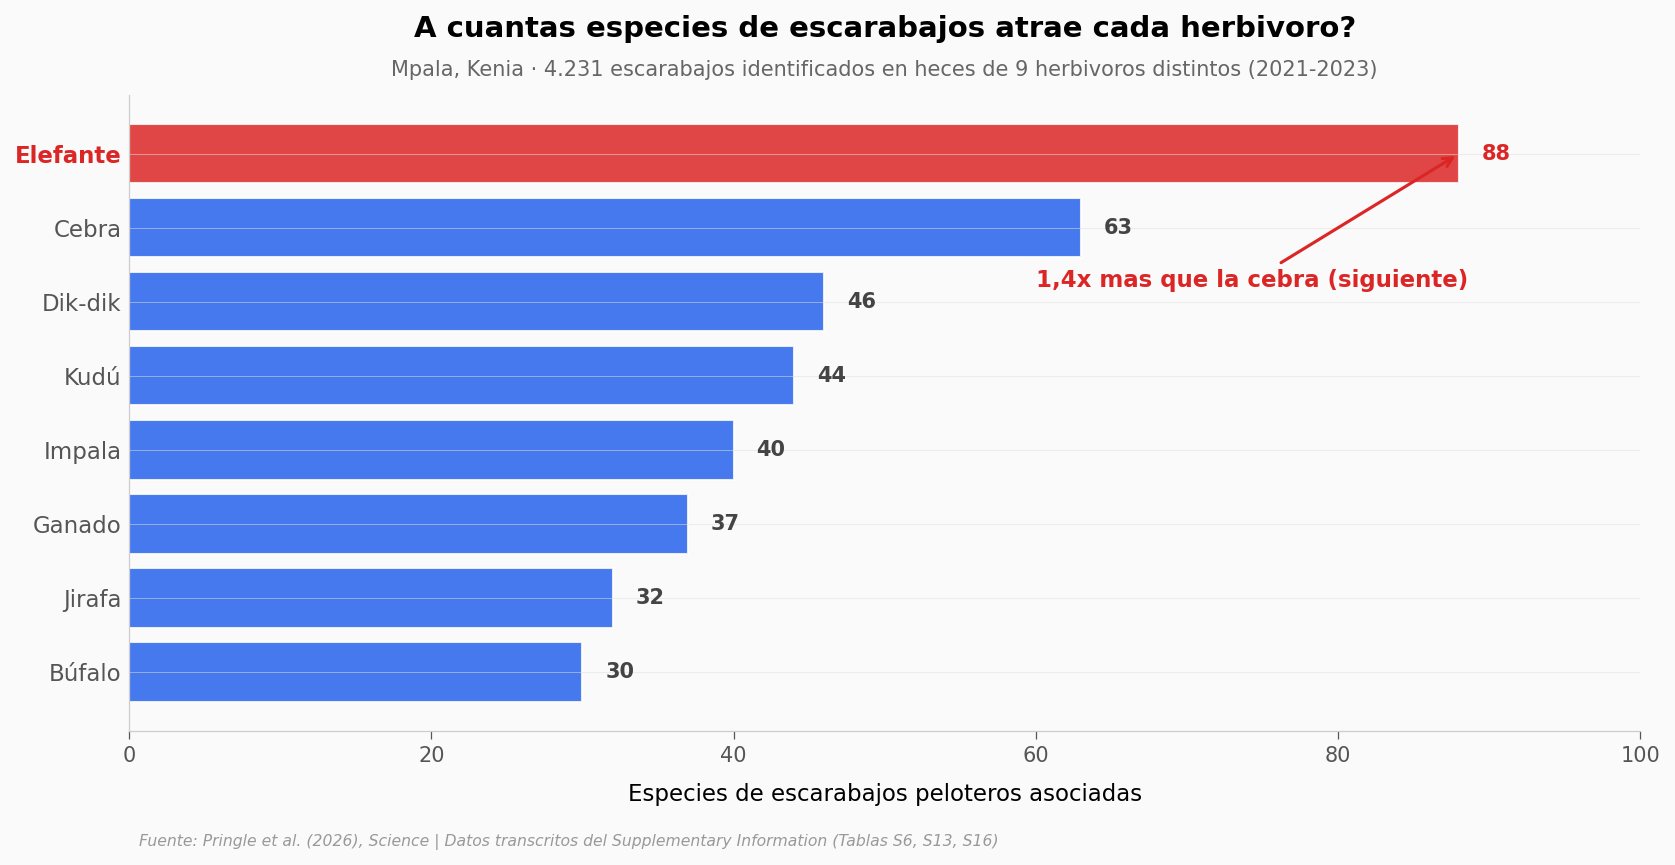

In [2]:
# Hero: comparacion elefante vs otros en metricas de la red trofica
# Eliminar humano del comparativo (el paper lo incluye pero no es animal silvestre)
df = herbivoros[herbivoros['herbivoro_es'] != 'Humano'].copy()
df = df.sort_values('beetle_richness', ascending=True)

fig, ax = plt.subplots(figsize=(13, 5.5))

colores = [COLOR_ELEFANTE if h == 'Elefante' else COLOR_OTROS for h in df['herbivoro_es']]
y = np.arange(len(df))
ax.barh(y, df['beetle_richness'], color=colores, alpha=0.85, edgecolor='white', linewidth=1)

for i, (val, name) in enumerate(zip(df['beetle_richness'], df['herbivoro_es'])):
    ax.text(val + 1.5, i, f'{int(val)}', va='center', fontsize=10,
            color=COLOR_ELEFANTE if name == 'Elefante' else '#444444',
            fontweight='bold')

ax.set_yticks(y)
ax.set_yticklabels(df['herbivoro_es'], fontsize=11)
for tick, name in zip(ax.get_yticklabels(), df['herbivoro_es']):
    if name == 'Elefante':
        tick.set_color(COLOR_ELEFANTE)
        tick.set_fontweight('bold')

ax.set_xlabel('Especies de escarabajos peloteros asociadas', fontsize=11)
ax.set_xlim(0, 100)
ax.set_title('A cuantas especies de escarabajos atrae cada herbivoro?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Mpala, Kenia · 4.231 escarabajos identificados en heces de 9 herbivoros distintos (2021-2023)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotacion elefante
elef_idx = df.reset_index(drop=True).index[df['herbivoro_es'].values == 'Elefante'][0]
ax.annotate('1,4x mas que la cebra (siguiente)',
            xy=(88, elef_idx), xytext=(60, elef_idx - 1.8),
            fontsize=11, fontweight='bold', color=COLOR_ELEFANTE,
            arrowprops=dict(arrowstyle='->', color=COLOR_ELEFANTE, lw=1.5))

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/red_centralidad.png', dpi=200, bbox_inches='tight')
plt.show()


**El elefante atrae a 88 especies de escarabajos. La cebra, segunda en el podio, atrae a 63. La jirafa solo a 32, el búfalo a 30.** En una métrica más fina (eigenvector centrality, que pondera con qué tan conectados están a su vez los escarabajos que llegan), el elefante saca 1,00 — el máximo posible. El resto promedia 0,61.

Lo que esto significa: si quitas a la cebra, los escarabajos que dependían de ella tienen alternativas razonables. Si quitas al elefante, una capa entera de la red se queda sin su nodo principal. La pregunta natural es: ¿qué pasa cuando eso ocurre de verdad?

El equipo lo probó.


## 15 años con elefantes, sin elefantes, sin nada

El experimento UHURU comenzó en 2009. Tres tratamientos en parcelas vecinas:

- **Abierto**: vallas que no excluyen a nadie. Funciona como control.
- **Sin megaherbívoros**: vallas de 2,4 m con cables electrificados que bloquean a elefantes y jirafas, pero dejan pasar al resto.
- **Sin nada**: vallas completas que excluyen a todos los herbívoros silvestres (de elefantes a dik-diks).

Después de 15 años, ¿qué tan distintas son las comunidades de escarabajos en cada parcela?


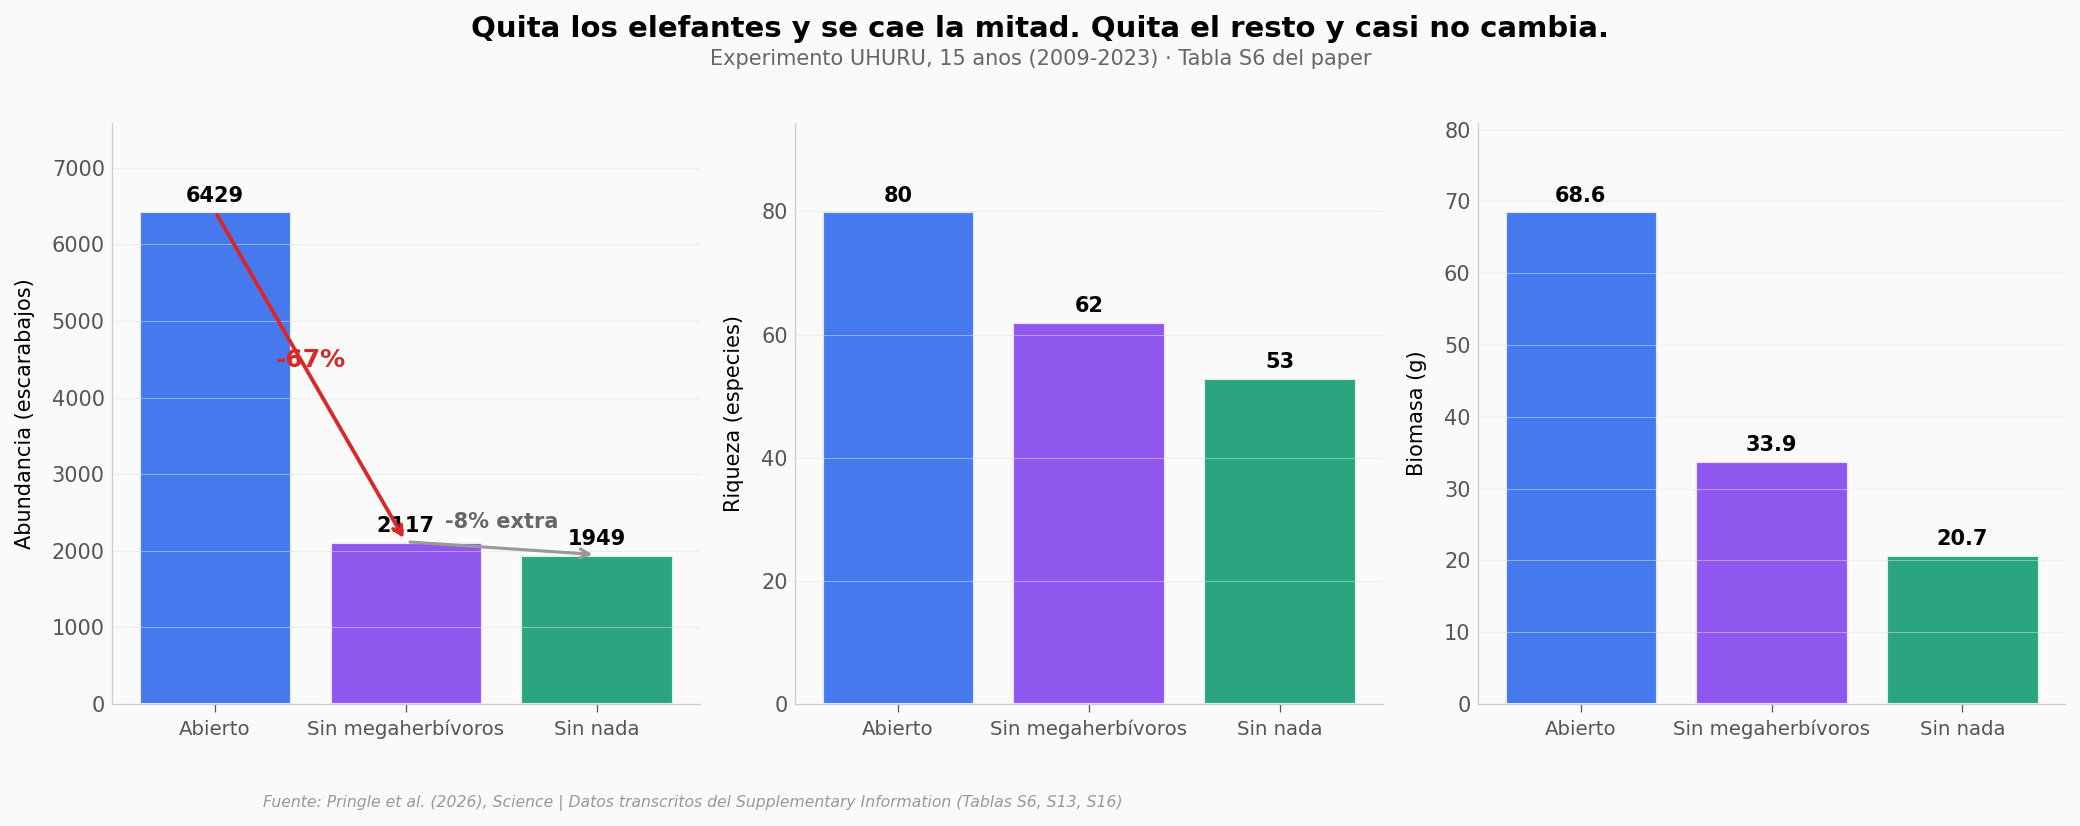

In [3]:
# Tres paneles: abundancia, riqueza, biomasa por tratamiento
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

metricas = [
    ('abundancia', 'Abundancia (escarabajos)'),
    ('riqueza_sp', 'Riqueza (especies)'),
    ('biomasa_g', 'Biomasa (g)'),
]
colores_trat = {'Abierto': COLOR_OTROS, 'Sin megaherbívoros': COLOR_MEGA, 'Sin nada': COLOR_TOTAL}

for ax, (col, label) in zip(axes, metricas):
    vals = exclusion[col].values
    labels = exclusion['tratamiento_es'].values
    colors = [colores_trat[t] for t in labels]
    ax.bar(range(len(vals)), vals, color=colors, alpha=0.85,
           edgecolor='white', linewidth=1.5)
    for i, v in enumerate(vals):
        txt = f'{int(v)}' if v == int(v) else f'{v:.1f}'
        ax.text(i, v + max(vals) * 0.02, txt,
                ha='center', fontsize=10, fontweight='bold')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9.5, rotation=0)
    ax.set_ylabel(label, fontsize=10)
    ax.set_ylim(0, max(vals) * 1.18)

# Caidas relativas anotadas en el panel de abundancia
ax = axes[0]
ax.annotate('', xy=(1, 2117), xytext=(0, 6429),
            arrowprops=dict(arrowstyle='->', color=COLOR_ELEFANTE, lw=1.8))
ax.text(0.5, 4400, '-67%', ha='center', fontsize=12, fontweight='bold', color=COLOR_ELEFANTE)
ax.annotate('', xy=(2, 1949), xytext=(1, 2117),
            arrowprops=dict(arrowstyle='->', color='#999999', lw=1.5))
ax.text(1.5, 2300, '-8% extra', ha='center', fontsize=10, fontweight='bold', color='#666666')

fig.suptitle('Quita los elefantes y se cae la mitad. Quita el resto y casi no cambia.',
             fontsize=14, fontweight='bold', y=1.04)
fig.text(0.5, 0.97, 'Experimento UHURU, 15 anos (2009-2023) · Tabla S6 del paper',
         fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.06, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/exclusion_experimento.png', dpi=200, bbox_inches='tight')
plt.show()


## La historia se repite donde el ganado desplazó a los elefantes

Cerca de Mpala hay otros dos ranchos: **Koija** y **Lekiji**. En ambos, el ganado doméstico desplazó a los elefantes hace décadas. Los modelos GLMM del paper predicen, controlando por esfuerzo de muestreo, cuántos escarabajos aparecerían en cada sitio bajo las mismas condiciones.

Esto NO es un experimento — es una comparación observacional. El equipo no quitó elefantes en Koija ni en Lekiji. Lo único que se puede afirmar es que **donde no hay elefantes, hay menos escarabajos**, y que el patrón coincide con lo que el experimento controlado mostró dentro de Mpala.


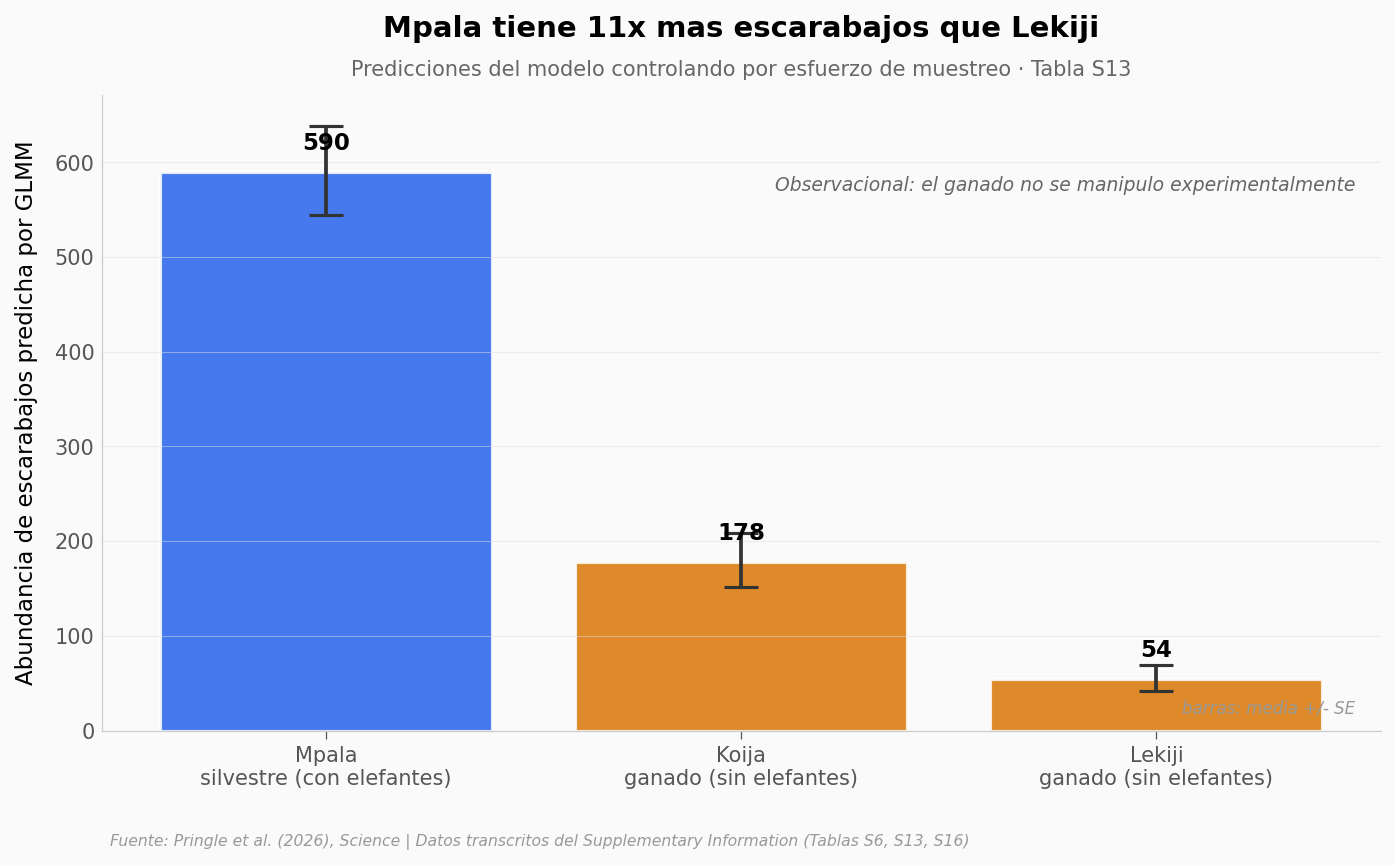

In [4]:
# Comparacion sitios — barras con error bars del GLMM (SE en log-scale)
fig, ax = plt.subplots(figsize=(11, 5.5))

orden = ['Mpala', 'Koija', 'Lekiji']
s = sitios.set_index('sitio').loc[orden].reset_index()
vals = s['abundancia_predicha'].values
# Intervalos aproximados: exp(intercept +/- SE) para mostrar incertidumbre
lo = np.exp(s['intercept_glmm'].values - s['se_glmm'].values)
hi = np.exp(s['intercept_glmm'].values + s['se_glmm'].values)
err = np.array([vals - lo, hi - vals])

colores_sitios = [COLOR_OTROS, COLOR_GANADO, COLOR_GANADO]
x = np.arange(len(vals))
ax.bar(x, vals, color=colores_sitios, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.errorbar(x, vals, yerr=err, fmt='_', color='#333333', capsize=8, capthick=1.5, markersize=0)

for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.04, f'{v:.0f}', ha='center', fontsize=11, fontweight='bold')

# Etiquetas tipo uso
tipos = {'Mpala': 'silvestre (con elefantes)',
         'Koija': 'ganado (sin elefantes)',
         'Lekiji': 'ganado (sin elefantes)'}
ax.set_xticks(x)
ax.set_xticklabels([f'{name}\n{tipos[name]}' for name in orden], fontsize=10)
ax.set_ylabel('Abundancia de escarabajos predicha por GLMM', fontsize=11)

ax.set_title('Mpala tiene 11x mas escarabajos que Lekiji',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Predicciones del modelo controlando por esfuerzo de muestreo · Tabla S13',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Anotacion de la nota observacional
ax.text(0.98, 0.85, 'Observacional: el ganado no se manipulo experimentalmente',
        transform=ax.transAxes, fontsize=9, color='#666666', ha='right', style='italic')

ax.text(0.98, 0.02, 'barras: media +/- SE', transform=ax.transAxes,
        fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/sitios_comparacion.png', dpi=200, bbox_inches='tight')
plt.show()


## ¿Qué tan keystone es un elefante?

En 1969, Robert Paine acuñó el concepto de *keystone species*: especies cuyo impacto sobre el ecosistema es desproporcionadamente grande respecto a su biomasa. Décadas después aparecieron formas de medirlo con número. Una es la **fuerza de interacción por individuo** (*interaction strength per capita*): cuánto efecto tiene UN individuo sobre la comunidad de escarabajos.

El paper la calculó para tres grupos: el elefante solo, los megaherbívoros como grupo (elefante + jirafa) y todos los ungulados de menos de 1.000 kg juntos (cebra, búfalo, kudú, impala, dik-dik). La diferencia es difícil de leer en escala lineal — necesita logaritmo.


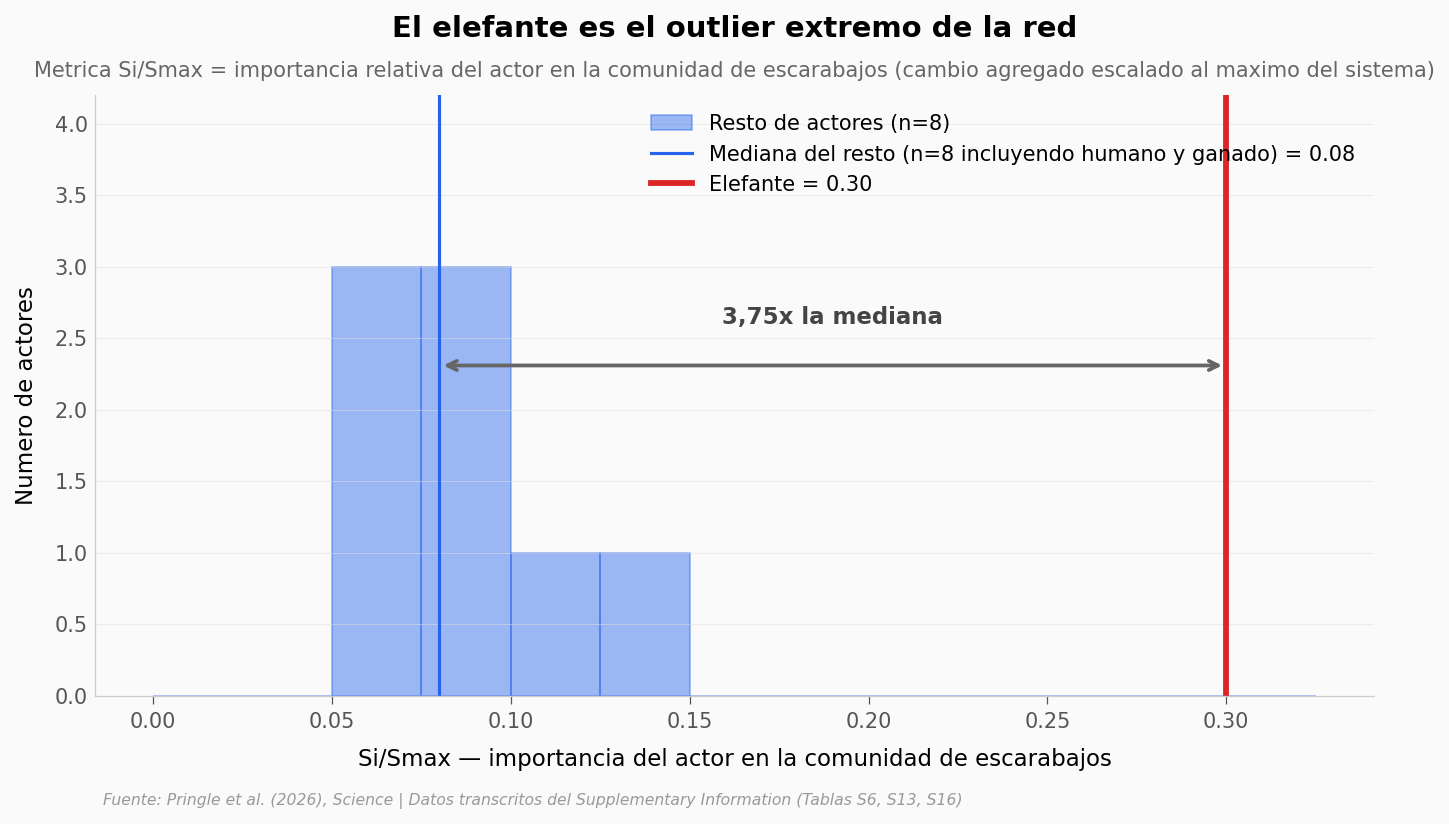

In [5]:
# Distribucion de Si/Smax (community importance index) entre los 9 actores de la red
# El elefante es un outlier extremo — visualizar como anomalia
fig, ax = plt.subplots(figsize=(11, 5.2))

valores = herbivoros['si_smax'].values
nombres = herbivoros['herbivoro_es'].values
elef_val = float(herbivoros[herbivoros['herbivoro_es'] == 'Elefante']['si_smax'].iloc[0])
otros = valores[nombres != 'Elefante']
mediana_otros = np.median(otros)

bins = np.arange(0, 0.35, 0.025)
n, bins_used, _ = ax.hist(otros, bins=bins, color=COLOR_OTROS, alpha=0.45,
                          edgecolor=COLOR_OTROS, linewidth=0.8,
                          label='Resto de actores (n=8)')
y_max = max(n.max(), 3) * 1.4
ax.set_ylim(0, y_max)

ax.axvline(x=mediana_otros, color=COLOR_OTROS, linewidth=1.5,
           label=f'Mediana del resto (n=8 incluyendo humano y ganado) = {mediana_otros:.2f}')
ax.axvline(x=elef_val, color=COLOR_ELEFANTE, linewidth=2.8,
           label=f'Elefante = {elef_val:.2f}')

# Flecha bidireccional
ax.annotate('', xy=(elef_val, y_max * 0.55), xytext=(mediana_otros, y_max * 0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.8))
ax.text((elef_val + mediana_otros) / 2, y_max * 0.62, '3,75x la mediana',
        ha='center', fontsize=11, fontweight='bold', color='#444444')

ax.set_xlabel('Si/Smax — importancia del actor en la comunidad de escarabajos',
              fontsize=11)
ax.set_ylabel('Numero de actores', fontsize=11)
ax.legend(fontsize=10, loc='upper right', framealpha=0.9)
ax.set_title('El elefante es el outlier extremo de la red',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03,
        'Metrica Si/Smax = importancia relativa del actor en la comunidad de escarabajos (cambio agregado escalado al maximo del sistema)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/anomalia_keystone.png', dpi=200, bbox_inches='tight')
plt.show()


### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|---|---|---|
| El elefante es la especie más conectada de la red | ✅ | Atrae a 88 especies de escarabajos (degree); siguiente es la cebra con 63. Ratio 1,40×; 2,17× vs el promedio de otras especies (40,6). Eigenvector centrality 1,00 vs 0,61 del resto |
| Quitar elefantes reduce abundancia y riqueza de escarabajos | ✅ | Tratamiento *Sin megaherbívoros* vs *Abierto*: −67% abundancia (GLMM β=−0,93, Z=−4,65, P<0,001), −22% riqueza, −51% biomasa |
| Quitar el resto de herbívoros tiene poco efecto adicional | ✅ | *Sin nada* vs *Sin megaherbívoros*: solo −8% abundancia extra (Padj=0,55) y −15% riqueza extra (Padj=0,10) — no significativo |
| Donde el ganado desplazó elefantes, hay menos escarabajos | ⚠️ | Mpala 590 escarabajos predichos vs Koija 178 (−70%) vs Lekiji 54 (−91%). El paper lo enmarca como comparación observacional, no como prueba causal |
| Un elefante equivale a 1.594 ungulados pequeños en aporte de heces | ✅ | Métrica community importance per capita: elefante 127,5 vs ungulados <1.000 kg 0,08. Ratio 1.594× |

> **Limitaciones:**
> - La métrica S<sub>i</sub>/S<sub>max</sub> agrega 9 actores (incluyendo humano y ganado doméstico), lo cual es un n pequeño para hablar de distribuciones.
> - El experimento de exclusión está en Mpala (sabana semiárida de Laikipia). Generalizar a otras sabanas africanas requiere asumir que las redes tróficas son similares — el paper lo discute en §4.
> - Las parcelas UHURU miden 4 ha. Los elefantes recorren cientos de km² al año; ahí está el efecto medible, pero a escalas mayores podrían entrar dinámicas que las parcelas no capturan.
> - La comparación Mpala / Koija / Lekiji es observacional. No se manipuló el ganado; lo que se puede afirmar es la asociación, no el mecanismo causal específico.


## Ahora tú

Cambia un valor de la configuración y vuelve a ejecutar. Tres preguntas para explorar:

1. **¿Cuánto se mueven los rangos si descartas al humano de la red?** El humano aparece en el paper como uno de los 9 *baits* probados — abre `herbivoros_dung.csv` y compara los rangos de centralidad incluyendo/excluyendo al humano.
2. **¿Qué tan correlacionada está la masa corporal con la centralidad?** Calcula la correlación de Spearman entre `masa_kg` y `beetle_richness` para los 7 herbívoros silvestres. ¿El rango captura toda la historia o el elefante distorsiona el resultado?
3. **¿Cuál es el efecto marginal de cada especie removida?** Para cada herbívoro, mira su S<sub>i</sub>/S<sub>max</sub> en `herbivoros_dung.csv`. Si lo quitas, pierdes esa proporción de la comunidad de escarabajos. ¿Qué pasa si los sumas todos? ¿La suma da 1 o más? ¿Por qué?


In [6]:
# --- EXPERIMENTA AQUI ---
# Pregunta 2: que tan correlacionada esta la masa corporal con la centralidad de la red?
from scipy import stats

silvestres = herbivoros[~herbivoros['herbivoro_es'].isin(['Humano', 'Ganado'])].copy()

# Spearman (no asume normalidad — apropiado para n=8)
rho, p = stats.spearmanr(silvestres['masa_kg'], silvestres['beetle_richness'])
print(f'Correlacion masa corporal vs riqueza de escarabajos (n={len(silvestres)})')
print(f'  Spearman rho = {rho:.2f}, P = {p:.3f}')

# Repetir excluyendo elefante para ver cuanto pesa el outlier
sin_elef = silvestres[silvestres['herbivoro_es'] != 'Elefante']
rho2, p2 = stats.spearmanr(sin_elef['masa_kg'], sin_elef['beetle_richness'])
print(f'\nLo mismo SIN el elefante (n={len(sin_elef)})')
print(f'  Spearman rho = {rho2:.2f}, P = {p2:.3f}')

print('\nLectura: con n=7 la correlacion masa-centralidad es practicamente nula (rho=0,04, p=0,94).')
print('La masa corporal por si sola NO explica la centralidad: la jirafa (800 kg) y el bufalo (646 kg)')
print('tienen baja centralidad. Lo distintivo del elefante no es solo su masa — es el unico que come')
print('arbustos enteros y procesa volumenes de heces muy superiores.')


Correlacion masa corporal vs riqueza de escarabajos (n=7)
  Spearman rho = 0.04, P = 0.939

Lo mismo SIN el elefante (n=6)
  Spearman rho = -0.54, P = 0.266

Lectura: con n=7 la correlacion masa-centralidad es practicamente nula (rho=0,04, p=0,94).
La masa corporal por si sola NO explica la centralidad: la jirafa (800 kg) y el bufalo (646 kg)
tienen baja centralidad. Lo distintivo del elefante no es solo su masa — es el unico que come
arbustos enteros y procesa volumenes de heces muy superiores.


## Fuentes

**Paper**: [Importance of elephants for dung beetle biodiversity and ecosystem functions](https://doi.org/10.1126/science.aeb7062)  
*Science, 2026-05-28*

**Supplementary Material**: [Supplementary Materials for: Importance of elephants for dung beetle biodiversity and ecosystem functions](https://www.science.org/doi/suppl/10.1126/science.aeb7062/suppl_file/science.aeb7062_sm.pdf)  
*Tablas y figuras suplementarias del paper (S1–S16, Figs S1–S12)*

**Referencias citadas**:
- [Data from: Importance of megaherbivores for dung beetle biodiversity and ecosystem functions](https://doi.org/10.5061/dryad.9p8cz8wwn) — *Dryad*

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

**Datos**: Transcritos del Supplementary Information del paper (Tablas S6, S13, S16) y de los datos de centralidad de red (§2.4d). El dataset Dryad asociado al paper estaba embargado al momento de generar este notebook.

**Licencia**: Datos derivados del paper publicado en *Science* (2026-05-28). Las transcripciones a CSV son nuestras; cualquier discrepancia con el SI original es nuestra responsabilidad. Código bajo MIT.

**Repo**: [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab)
